In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = fetch_openml(data_id=41554, as_frame=True)

In [3]:
df = data.frame.copy()

In [4]:
print("Shape of full data:", df.shape)
print("Column names:")
print(df.columns)

Shape of full data: (359, 18)
Column names:
Index(['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4',
       'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb',
       'Zn', 'Cd', 'Co', 'Cu'],
      dtype='object')


In [5]:
target_col = "Cd" 

In [6]:

y = df[target_col]
X = df.drop(columns=[target_col])

In [7]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

In [8]:
df2 = X.copy()
df2["Cadmium"] = pd.to_numeric(y, errors="coerce")
df2 = df2.dropna()

X = df2.drop("Cadmium", axis=1)
y = df2["Cadmium"]

print("\nAfter cleaning:")
print("X shape:", X.shape)
print("y shape:", y.shape)


After cleaning:
X shape: (359, 17)
y shape: (359,)



First 5 rows:
    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Co     Cu  Cadmium  
0       1       0       0  38.32  21.32  77.36  92.56   9.32  25.72    1.740  
1       0       0       0  40.20  29.72  77.88  73.56  10.00  24.76    1.335  
2       1       0       0  47.00  21.40  30.80  64.80  10.60   8.88    1.610  
3       0       0       0  43.52  29.72  56.40  90.00  11.92  22.70    2.150  
4       0       0       1  38.52  26.20  66.40  88.40  16.32  34.32    1.565  

Summary statistics:
             Xl

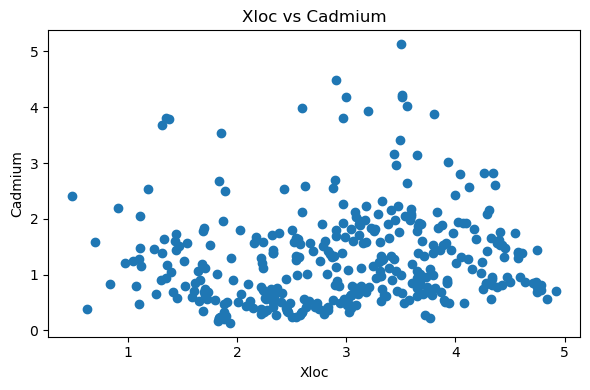

In [9]:
print("\nFirst 5 rows:")
print(df2.head())

print("\nSummary statistics:")
print(df2.describe())

# Scatter plot: first feature vs Cadmium
plt.figure(figsize=(6, 4))
plt.scatter(X.iloc[:, 0], y)
plt.xlabel(X.columns[0])
plt.ylabel("Cadmium")
plt.title(X.columns[0] + " vs Cadmium")
plt.tight_layout()
plt.show()

In [10]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [12]:
linear = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

linear.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso()

In [13]:
y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

In [14]:
def check_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(name)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print()

check_model("Linear Regression", y_test, y_pred_linear)
check_model("Ridge Regression", y_test, y_pred_ridge)
check_model("Lasso Regression", y_test, y_pred_lasso)

Linear Regression
RMSE: 0.8328470808943182
R2 Score: -0.06897541552734565

Ridge Regression
RMSE: 0.543680524958258
R2 Score: 0.5444618700451274

Lasso Regression
RMSE: 0.8087172166439488
R2 Score: -0.007930435176925155



In [15]:
print("Linear Coefficients:")
print(linear.coef_)

print("\nRidge Coefficients:")
print(ridge.coef_)

print("\nLasso Coefficients:")
print(lasso.coef_)

Linear Coefficients:
[-1.52636106e-01  4.35489373e-01  4.17901890e-02 -6.66587332e-02
  1.05519664e-02  5.58329578e-02  8.56176263e-02  5.69267814e-02
 -6.57678219e-02 -8.22630949e-03 -8.51524800e-02  8.86594978e-01
 -6.25355180e-01 -5.36648895e-01 -2.86524139e-01  2.88164528e-01
  3.81827806e-01 -1.16107267e-01  8.79875674e-02  2.75238893e-01
 -2.45799755e-01 -1.04820650e-01  2.14590718e-02 -2.28898257e-01
  1.27735788e-01  4.49287726e-02  6.22322894e-02 -1.57998299e-01
 -2.29803299e-01 -7.99946738e-01 -7.98999718e-01  1.96001005e+00
  5.32211123e-01 -2.75045908e-01 -2.25703242e-01 -4.22650387e-03
  2.17299432e-01  1.09882955e-01  2.77746390e-01  9.48857911e-03
  2.15910942e-01  2.55054165e-02 -9.88379853e-03  1.85739321e-01
 -6.56017301e-01  8.67833029e-01  5.52332928e-01 -4.14582694e-01
 -7.47936820e-01 -3.38991789e-02  4.17901890e-02 -6.86950496e-16
 -8.60422844e-16 -1.23512311e-15  2.77796239e-02  7.69157662e-03
  6.75088490e-02 -3.30806015e-03 -3.49720253e-15 -1.23014582e-01
 -4.

In [16]:
feature_names = poly.get_feature_names_out(X.columns)
zero_features = []

for i in range(len(lasso.coef_)):
    if lasso.coef_[i] == 0:
        zero_features.append(feature_names[i])

print("\nFeatures reduced to zero by Lasso:")
print(zero_features)


Features reduced to zero by Lasso:
['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4', 'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb', 'Zn', 'Co', 'Cu', 'Xloc^2', 'Xloc Yloc', 'Xloc Landuse_1', 'Xloc Landuse_2', 'Xloc Landuse_3', 'Xloc Landuse_4', 'Xloc Rock_1', 'Xloc Rock_2', 'Xloc Rock_3', 'Xloc Rock_4', 'Xloc Rock_5', 'Xloc Cr', 'Xloc Ni', 'Xloc Pb', 'Xloc Zn', 'Xloc Co', 'Xloc Cu', 'Yloc^2', 'Yloc Landuse_1', 'Yloc Landuse_2', 'Yloc Landuse_3', 'Yloc Landuse_4', 'Yloc Rock_1', 'Yloc Rock_2', 'Yloc Rock_3', 'Yloc Rock_4', 'Yloc Rock_5', 'Yloc Cr', 'Yloc Ni', 'Yloc Pb', 'Yloc Zn', 'Yloc Co', 'Yloc Cu', 'Landuse_1^2', 'Landuse_1 Landuse_2', 'Landuse_1 Landuse_3', 'Landuse_1 Landuse_4', 'Landuse_1 Rock_1', 'Landuse_1 Rock_2', 'Landuse_1 Rock_3', 'Landuse_1 Rock_4', 'Landuse_1 Rock_5', 'Landuse_1 Cr', 'Landuse_1 Ni', 'Landuse_1 Pb', 'Landuse_1 Zn', 'Landuse_1 Co', 'Landuse_1 Cu', 'Landuse_2^2', 'Landuse_2 Landuse_3', 'Landuse_2 Landuse_4', 'Landuse_